In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df= pd.read_csv('output.csv')
df.head()

,comment
0,Two young guys with shaggy hair look at their ...
1,"Two young , White males are outside near many ..."
2,Two men in green shirts are standing in a yard .
3,A man in a blue shirt standing in a garden .
4,Two friends enjoy time spent together .


In [ ]:
df.isnull().sum()

,0
comment,0


In [ ]:
df.describe()

,comment
count,158914
unique,158438
top,Two dogs playing in the snow .
freq,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158914 entries, 0 to 158913
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   comment  158914 non-null  object
dtypes: object(1)
memory usage: 1.2+ MB


In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

def preprocess_data(df):
    # Convert all text to lowercase
    df['comment'] = df['comment'].str.lower()

    # Remove special characters and numbers
    df['comment'] = df['comment'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

    # Tokenization
    df['comment'] = df['comment'].apply(word_tokenize)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    df['comment'] = df['comment'].apply(lambda x: [word for word in x if word not in stop_words])

    # Stemming
    # ps = PorterStemmer()
    # df['comment'] = df['comment'].apply(lambda x: [ps.stem(word) for word in x])

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    df['comment'] = df['comment'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

     # Join tokens back into a single string
    df['comment'] = df['comment'].apply(lambda x: ' '.join(x))

    return df

# Assuming 'df' is your DataFrame
df = preprocess_data(df)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df.head()

,comment
0,two young guy shaggy hair look hand hanging yard
1,two young white male outside near many bush
2,two men green shirt standing yard
3,man blue shirt standing garden
4,two friend enjoy time spent together


In [ ]:
import torch
import torchvision
import sentence_transformers
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity


comments = df['comment'].dropna().tolist()


model = SentenceTransformer('all-MiniLM-L6-v2')


embeddings = model.encode(comments, show_progress_bar=True)

from sklearn.preprocessing import normalize
embeddings_norm = normalize(embeddings)

kmeans = KMeans(n_clusters=20, random_state=0)
labels = kmeans.fit_predict(embeddings_norm)


df['cluster'] = labels
df.to_excel("clustered_comments01.xlsx", index=False)

for i in range(5):
    print(f"\nCluster {i}")
    print(df[df['cluster'] == i]['comment'].head(3).to_string(index=False))



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4967 [00:00<?, ?it/s]


Cluster 0
man sits chair holding large stuffed animal lion
  man sitting chair holding large stuffed animal
      man completes finishing touch stuffed lion

Cluster 1
      woman talking cellphone wearing rollerskates
young woman dark hair wearing glass putting whi...
lady black top glass sprinkling powdered sugar ...

Cluster 2
large crowd people stand outside front entrance...
                  group people walking city street
                crowd portrayed near metro station

Cluster 3
young male kneeling front hockey goal hockey st...
person green outfit helmet swinging baseball ba...
girl playing softball hit ball almost directly ...

Cluster 4
                    man blue shirt standing garden
someone blue shirt hat standing stair leaning w...
          man green hold guitar man observes shirt


In [ ]:
# Identifying the correct number of clusters using the elbow method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np


# Function to calculate the inertia and silhouette score for a range of clusters
def calculate_inertia_and_silhouette(X, max_clusters):
    inertia = []
    silhouette_scores = []

    for n_clusters in range(2, max_clusters + 1,5):
        kmeans = KMeans(n_clusters=n_clusters, random_state=0)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
        print(n_clusters)

    return inertia, silhouette_scores

# Calculate inertia and silhouette scores for a range of clusters
max_clusters = 50
inertia, silhouette_scores = calculate_inertia_and_silhouette(embeddings_norm, max_clusters)




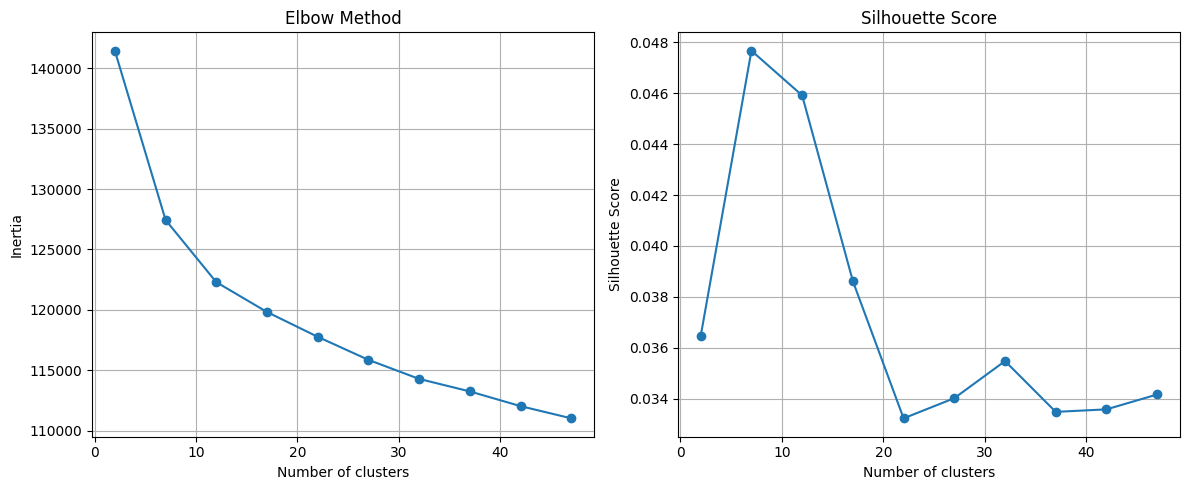

In [ ]:
cluster_range=[2,7,12,17,22,27,32,37,42,47]
max_clusters = 50
# inertia, silhouette_scores, cluster_range = calculate_inertia_and_silhouette(embeddings_norm, max_clusters)
# Plotting the elbow method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.plot(cluster_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=12, random_state=0)
labels = kmeans.fit_predict(embeddings_norm)


df['cluster'] = labels
df.to_excel("new_clustered_comments01.xlsx", index=False)

# save the trained model
import pickle
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)




In [ ]:
df1=pd.read_csv('output.csv')
df1 = df1.rename(columns={'comment': 'orignal_comment'})
merged_df = pd.concat([df1, df], axis=1)

# merged_df.head()

In [ ]:
for i in range(12):
    print(f"\nCluster {i}")
    print(merged_df[merged_df['cluster'] == i]['orignal_comment'].head(5).to_string(index=False))


Cluster 0
      A man in a blue shirt standing in a garden .
Workers look down from up above on a piece of e...
Someone in a blue shirt and hat is standing on ...
A man in a blue shirt is standing on a ladder c...
A man on a ladder cleans the window of a tall b...

Cluster 1
Woman talking on cellphone and wearing rollersk...
 A woman with a large purse is walking by a gate .
Some women are standing in front of a bus with ...
Several women stand on a city street with tall ...
 A group of women are standing in front of a bus .

Cluster 2
A little girl in a pink dress going into a wood...
A little girl climbing the stairs to her playho...
    A little girl climbing into a wooden playhouse
             A girl going into a wooden building .
A girl is on rollerskates talking on her cellph...

Cluster 3
A young male kneeling in front of a hockey goal...
A boy with a stick kneeling in front of a goali...
A person in a green outfit and helmet is swingi...
A girl playing softball hits the ball 

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


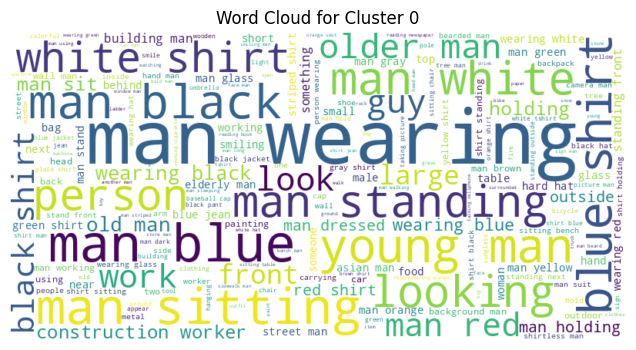

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


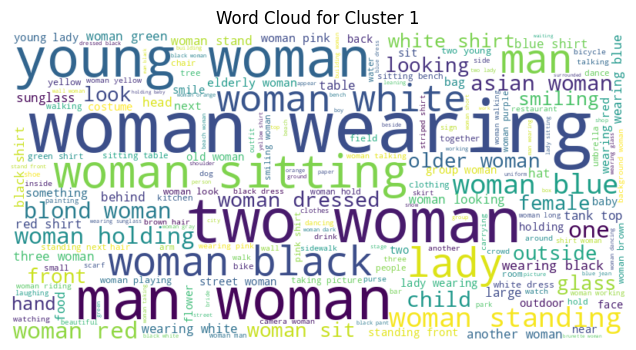

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


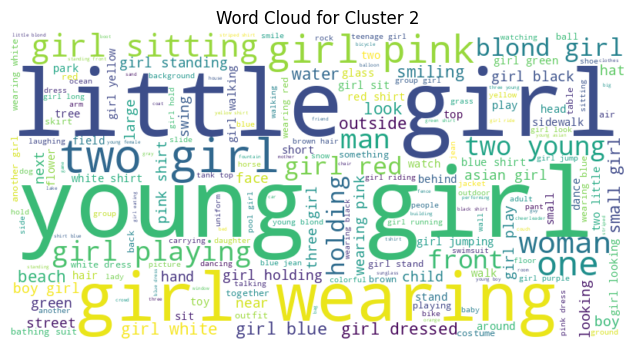

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


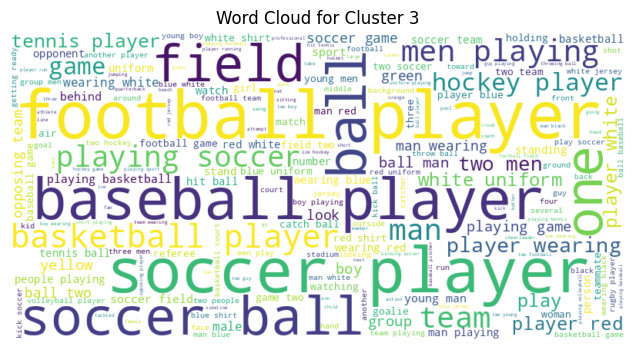

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


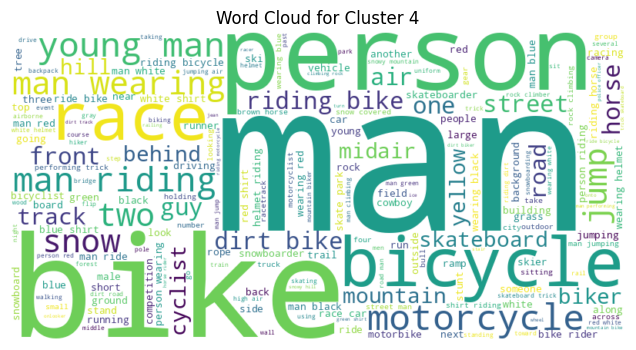

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


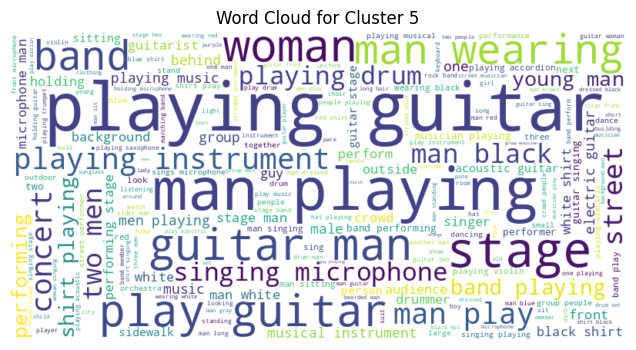

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


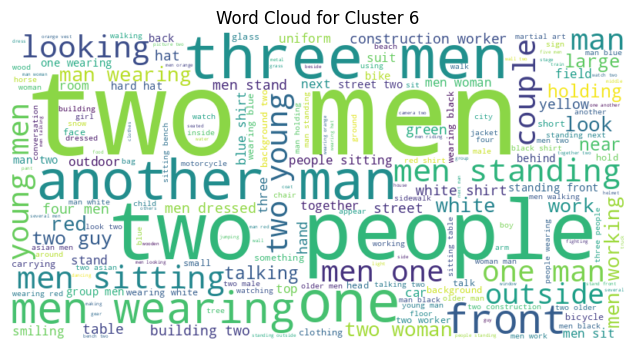

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


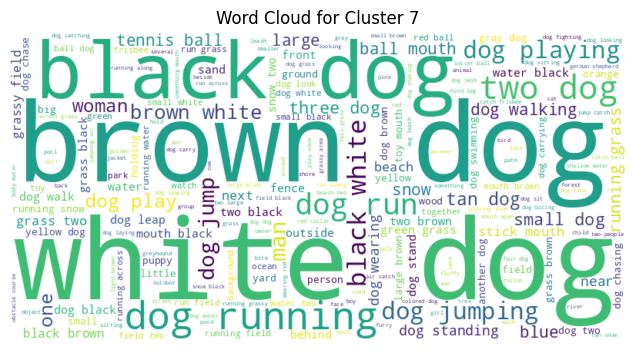

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


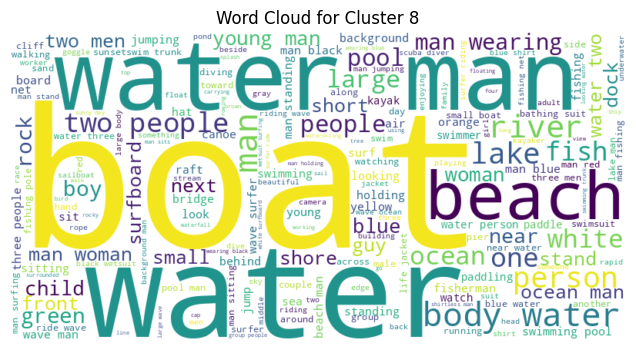

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


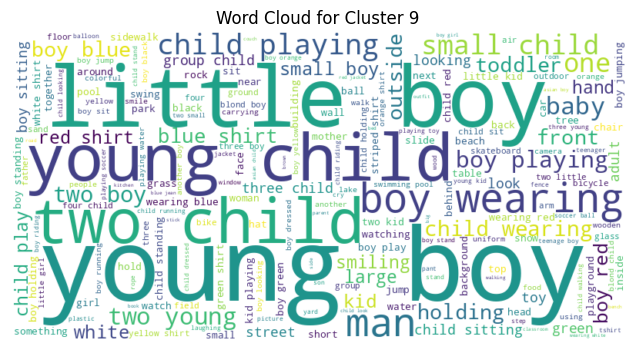

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


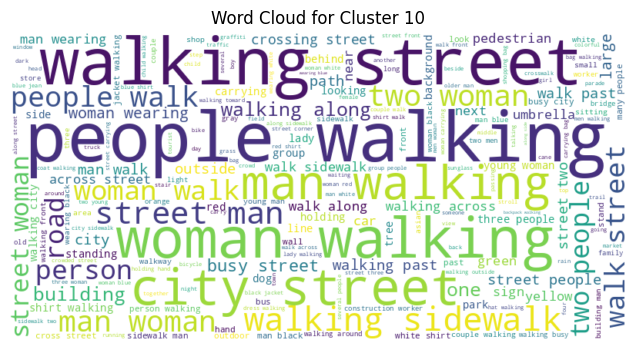

-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------
-------------------------------------------------------------------


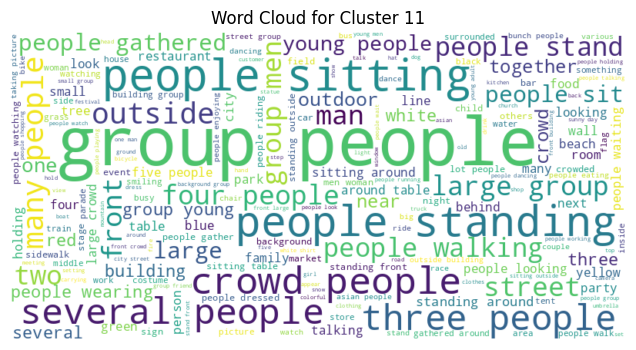

In [ ]:
from wordcloud import WordCloud

for i in range(df['cluster'].nunique()):
    text = " ".join(df[df['cluster'] == i]['comment'].tolist())
    wordcloud = WordCloud(background_color='white', width=800, height=400).generate(text)

    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation='bilinear')

    print("-------------------------------------------------------------------")
    print("-------------------------------------------------------------------")
    print("-------------------------------------------------------------------")
    print("-------------------------------------------------------------------")
    print("-------------------------------------------------------------------")
    plt.axis('off')
    plt.title(f'Word Cloud for Cluster {i}')
    plt.show()

Enter a comment (or type 'exit' to stop): a man walking downstair

The input comment belongs to cluster: 10


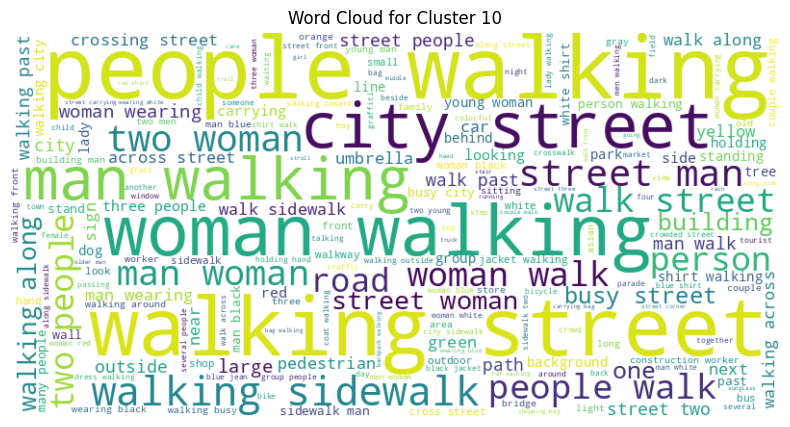

In [ ]:

user_input = input("Enter a comment (or type 'exit' to stop): ")


embedding = model.encode([user_input])
embedding_norm = normalize(embedding)


predicted_cluster = kmeans.predict(embedding_norm)[0]
print(f"\nThe input comment belongs to cluster: {predicted_cluster}")


cluster_comments = df[df['cluster'] == predicted_cluster]['comment']
text_blob = " ".join(cluster_comments)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_blob)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f"Word Cloud for Cluster {predicted_cluster}")
plt.show()